#### Inverse kinematics of `Panda` cabinet environment

In [1]:
from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.qt import *

from package.panda_env import * 

from PyQt5.QtWidgets import QApplication
app = QApplication(sys.argv)

Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.


In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files=[
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/cabinet/cabinet_half_closed.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_cabinet_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [4] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/cabinet/cabinet_half_closed.xml]
  - [3] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_cabinet_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[28]
 [0/28] [world] parent:[world] mass:[0.00]kg
 [1/28] [panda_base] parent:[world] mass:[0.00]kg
 [2/28] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/28] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/28] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/28] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/28] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/28] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/28] [panda_link_6] parent:[panda_link_5] mass:[1.50]

MuJoCo model loaded from [xml/panda_cabinet_scene.xml].


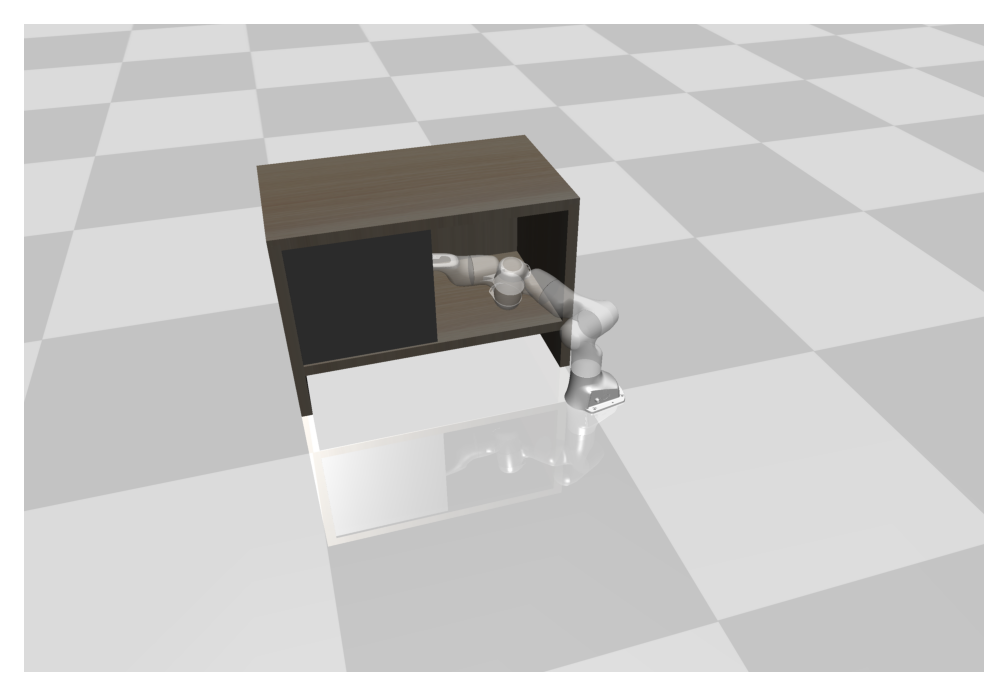

Done.


In [3]:
# Configuration
panda_joints          = get_panda_joint_names()
inspire_joints        = get_inspire_joint_names()
inspire_active_joints = env.get_active_among_joints(inspire_joints)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
qactive_inspire0      = get_qactive_inspire()
q_inspire0            = get_q_inspire(env)
q_pandas              = get_q_pandas_cabinet()

# Initialize env
set_panda_cabinet_env(env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0)

# Initialize sliders and buttons
T_palm    = get_T_palm_panda_inspire(env)
prpy_palm = np.hstack([t2p(T_palm),r2rpy(t2r(T_palm))])
sliders = MultiSliderQtWidget(
    title         = "Panda IK pose target",
    window_width  = 0.2,
    window_height = 0.2,
    label_texts   = ['X','Y','Z','Roll','Pitch','Yaw'],
    slider_mins   = prpy_palm-np.array([1,1,1,180,180,180]),
    slider_maxs   = prpy_palm+np.array([1,1,1,180,180,180]),
    slider_vals   = prpy_palm,
)
buttons = MultiRadioQtWidget(
    title         = "Set Panda joint position",
    label_texts   = ["Panda pose"],
    option_texts  = [["init","final"]],
    initial_texts = ["init"],
    y_offset      = 0.25,
    window_width  = 0.2,
    window_height = 0.05,
)

# Initialize IK solver (RevPriBase)
ik_env = MuJoCoParser(rel_xml_path=env.rel_xml_path) # separate env for IK
ik_solver = SitePositionIKSolverRevPriBase(
    ik_env            = ik_env,
    max_ik_tick       = 100,
    ik_stepsize_rev   = 0.5,      # [rad]
    ik_stepsize_pri   = 0.02,     # [m]
    ik_update_th_rev  = 10*D2R,
    dls_damping       = 1e-4,
    max_probe_rev     = 3*D2R,    # [rad]
    max_probe_pri     = 0.01,     # [m]
    k_null            = 0.0,      # <= having nullspace control might deteriorate joint tracking
    q_home_rev_pri    = env.get_qpos(joint_names=env.rev_pri_joint_names),
)

# Loop
ik_err_best = 0.0
while env.is_viewer_alive():

    # Set Panda joint position
    if buttons.is_toggled(label_text="Panda pose"):
        panda_pose = buttons.get_option("Panda pose")
        if panda_pose=="init":
            env.forward(q=q_pandas['init'],joint_names=panda_joints)
        if panda_pose=="final":
            env.forward(q=q_pandas['final'],joint_names=panda_joints)
        T_palm = get_T_palm_panda_inspire(env)
        sliders.set_values(values=np.hstack((t2p(T_palm),r2rpy(t2r(T_palm)))))

    # Solve IK
    p_palm_trgt = sliders.get_values()[:3]
    R_palm_trgt = rpy2r(sliders.get_values()[3:]*D2R)
    ik_err_best = solve_ik_panda_palm(env,ik_solver,p_palm_trgt,R_palm_trgt)

    # Move attached cylinder
    T_palm = get_T_palm_panda_inspire(env)
    T_cylinder = view_in_world(T=p2t(p_cylinder_offset0),T_wl=T_palm)
    env.set_T('body_cylinder','base_body',T_cylinder)

    # Get contact information (after FK)
    contact_info = env.get_contact_info()

    # Render
    env.viewer_text_overlay('#contact','[%d]'%(contact_info['n_contact']))
    env.viewer_text_overlay('contact dist','[%.3f]'%(contact_info['min_contact_dist']))
    env.viewer_text_overlay('IK error','[%.3f]'%(ik_err_best))
    env.plot_global_coordinate_axes()
    env.plot_contact_info()
    ik_solver.render(env,r=0.005,alpha=0.5,scale_radius_by_weight=True)
    env.render()
    app.processEvents()

# Final image show
imshow(env.final_rgb_img)

# Close
sliders.close()
buttons.close()
print("Done.")
